In [240]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [68]:
data_path = r"C:\Users\Admin\Desktop\seoul bike prediction\data\SeoulBikeData.csv"
df = pd.read_csv(data_path,encoding="unicode_escape")
df.shape

(8760, 14)

In [69]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [364]:
df.columns

Index(['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)',
       'Rainfall(mm)', 'Snowfall (cm)', 'Holiday', 'Functioning Day', 'Day',
       'Month', 'year', 'Spring', 'Summer', 'Winter', 'Monday', 'Saturday',
       'Sunday', 'Thursday', 'Tuesday', 'Wednesday'],
      dtype='object')

In [73]:
 df.tail()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
8759,30/11/2018,584,23,1.9,43,1.3,1909,-9.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [77]:
df.describe(include="all").T #.t means transpose function 


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,8760,365,01/12/2017,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rented Bike Count,8760.0,NaN,NaN,NaN,704.602055,644.997468,0.0,191.0,504.5,1065.25,3556.0
Hour,8760.0,NaN,NaN,NaN,11.5,6.922582,0.0,5.75,11.5,17.25,23.0
Temperature(°C),8760.0,NaN,NaN,NaN,12.882922,11.944825,-17.8,3.5,13.7,22.5,39.4
Humidity(%),8760.0,NaN,NaN,NaN,58.226256,20.362413,0.0,42.0,57.0,74.0,98.0
Wind speed (m/s),8760.0,NaN,NaN,NaN,1.724909,1.0363,0.0,0.9,1.5,2.3,7.4
Visibility (10m),8760.0,NaN,NaN,NaN,1436.825799,608.298712,27.0,940.0,1698.0,2000.0,2000.0
Dew point temperature(°C),8760.0,NaN,NaN,NaN,4.073813,13.060369,-30.6,-4.7,5.1,14.8,27.2
Solar Radiation (MJ/m2),8760.0,NaN,NaN,NaN,0.569111,0.868746,0.0,0.0,0.01,0.93,3.52
Rainfall(mm),8760.0,NaN,NaN,NaN,0.148687,1.128193,0.0,0.0,0.0,0.0,35.0


In [79]:
df.isnull().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

In [81]:
df["Date"] = pd.to_datetime(df["Date"], format='mixed')
df["weekday"] = df["Date"].dt.day_name()
df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year

df.drop("Date",axis = 1,inplace = True)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rented Bike Count          8760 non-null   int64  
 1   Hour                       8760 non-null   int64  
 2   Temperature(°C)            8760 non-null   float64
 3   Humidity(%)                8760 non-null   int64  
 4   Wind speed (m/s)           8760 non-null   float64
 5   Visibility (10m)           8760 non-null   int64  
 6   Dew point temperature(°C)  8760 non-null   float64
 7   Solar Radiation (MJ/m2)    8760 non-null   float64
 8   Rainfall(mm)               8760 non-null   float64
 9   Snowfall (cm)              8760 non-null   float64
 10  Seasons                    8760 non-null   object 
 11  Holiday                    8760 non-null   object 
 12  Functioning Day            8760 non-null   object 
 13  weekday                    8760 non-null   objec

In [85]:
df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,weekday,Day,Month,year
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Thursday,12,1,2017
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Thursday,12,1,2017
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,Thursday,12,1,2017
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Thursday,12,1,2017
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Thursday,12,1,2017


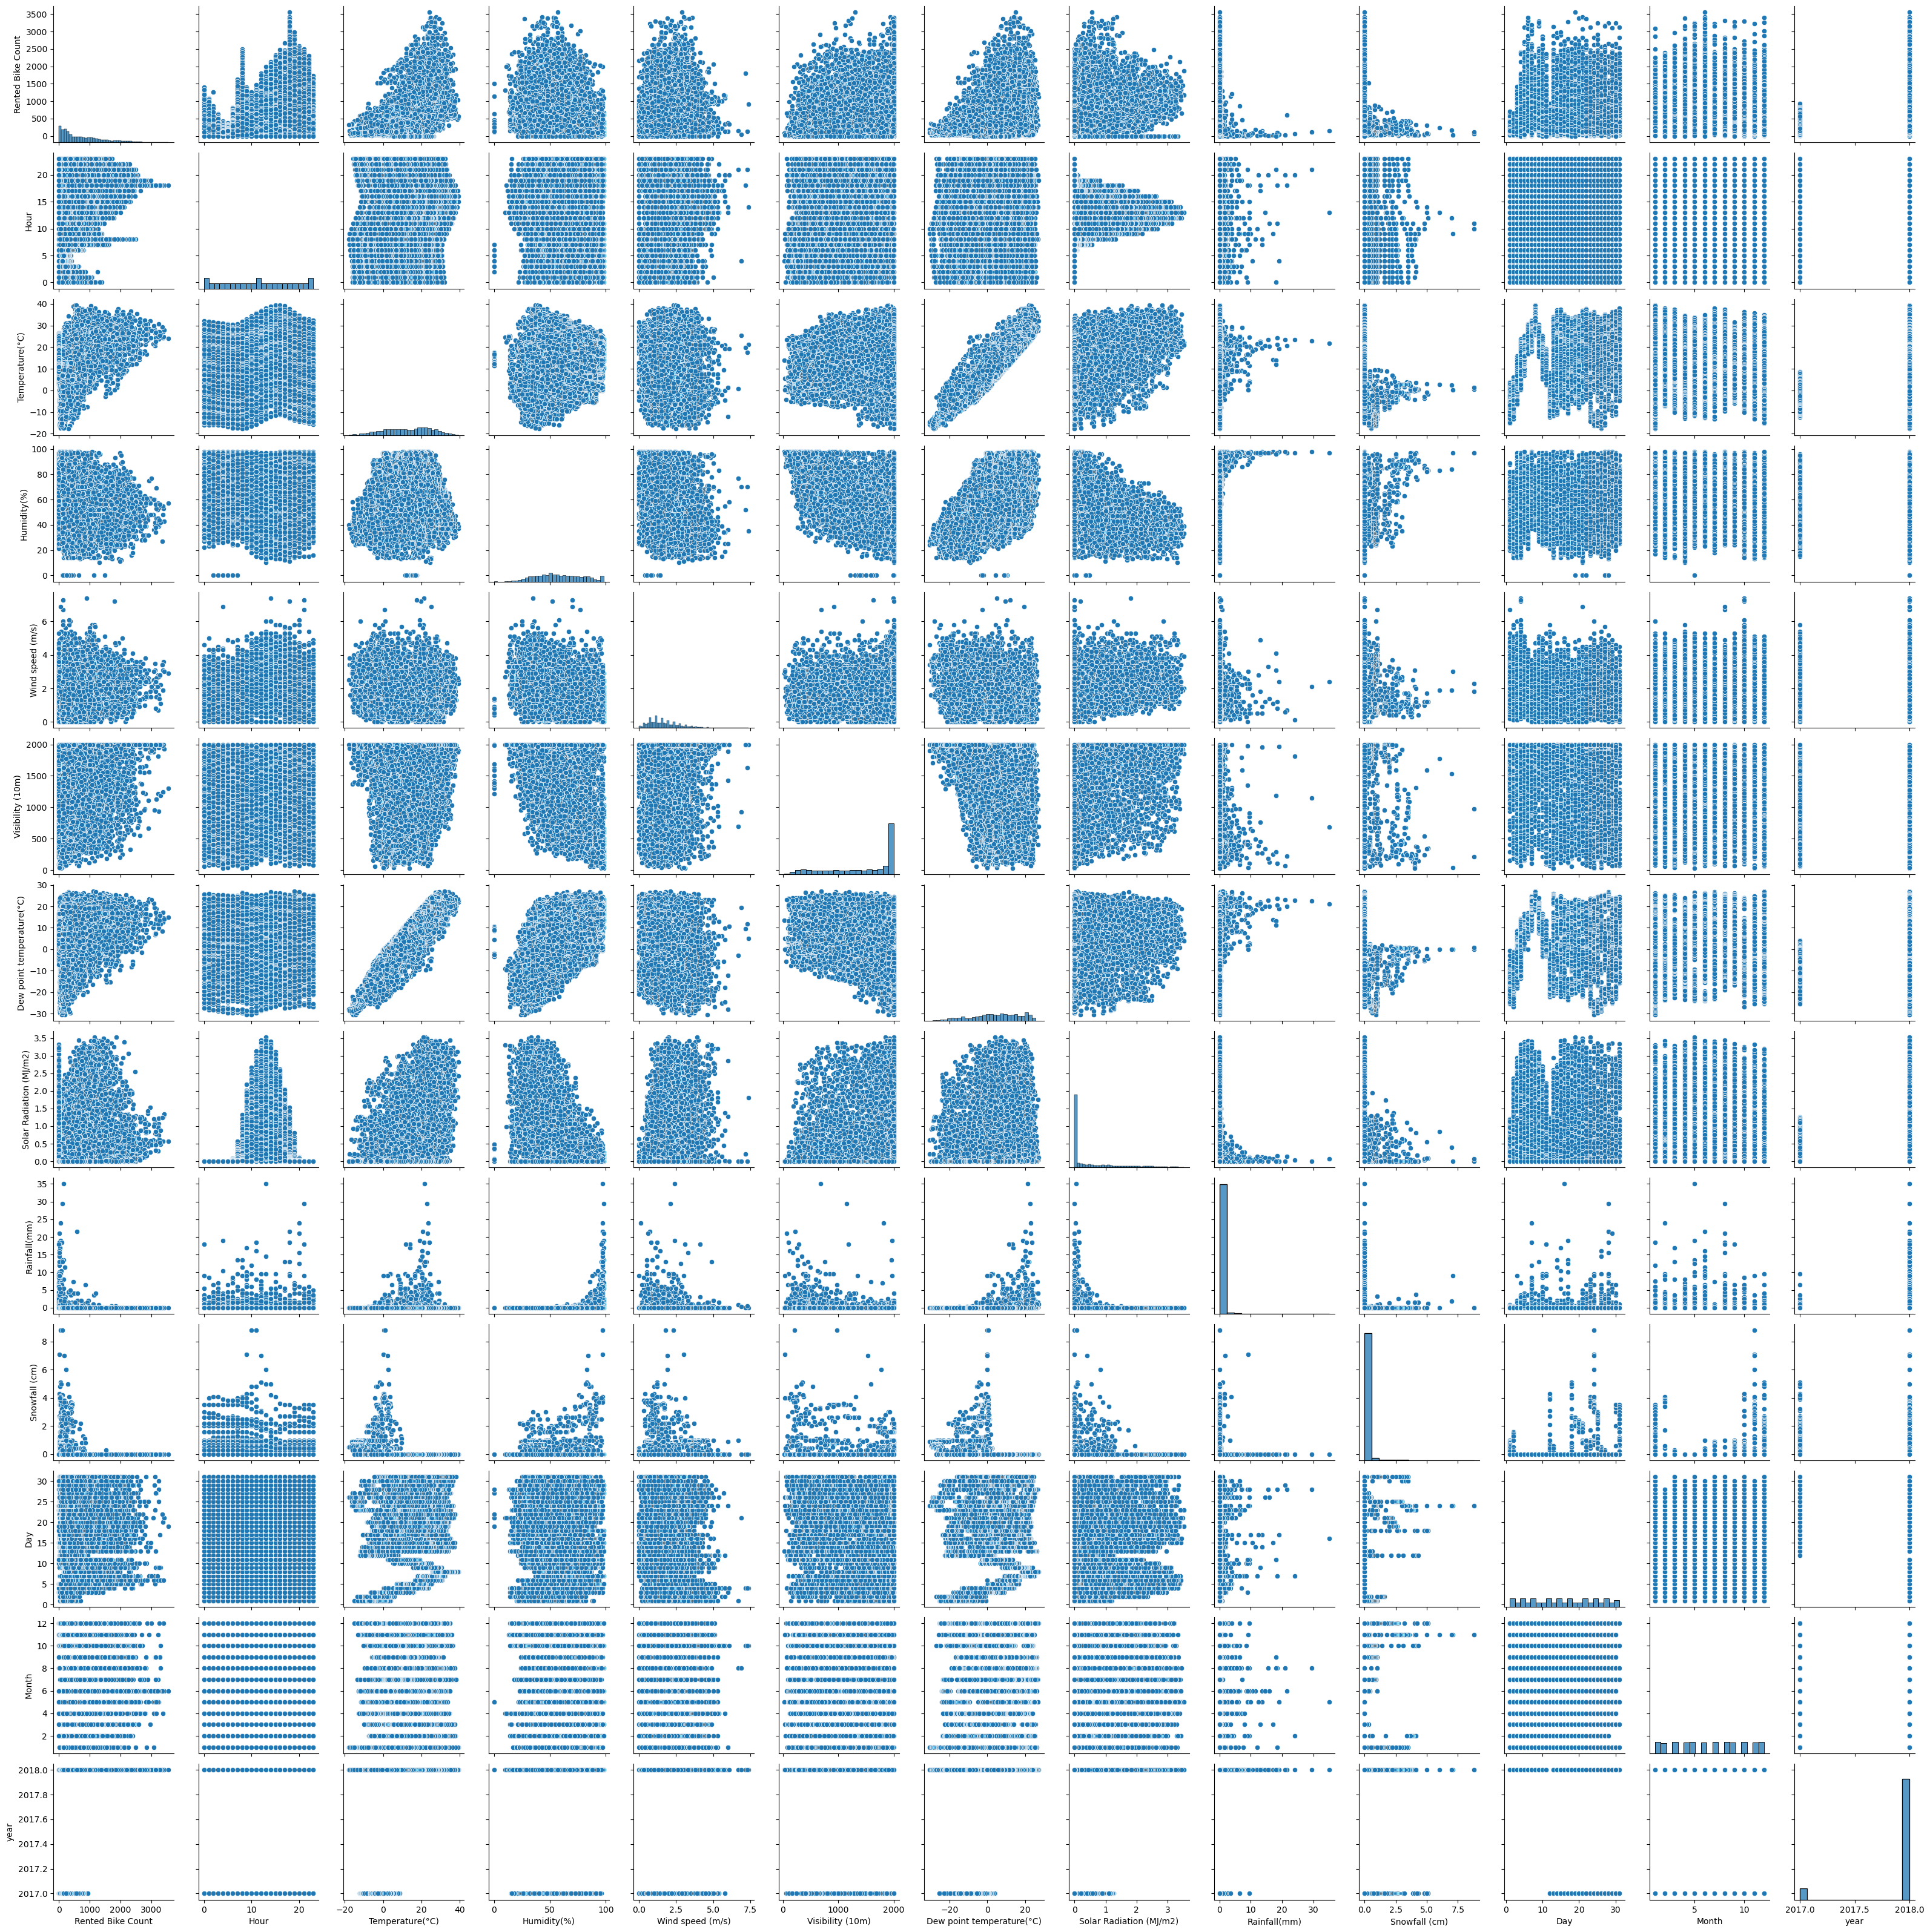

In [90]:
#eda
sns.pairplot(df)# for data visualization by visualising we can tell that in 2017 sale was compartivly low than in 2018 

<Axes: xlabel='Month', ylabel='Rented Bike Count'>

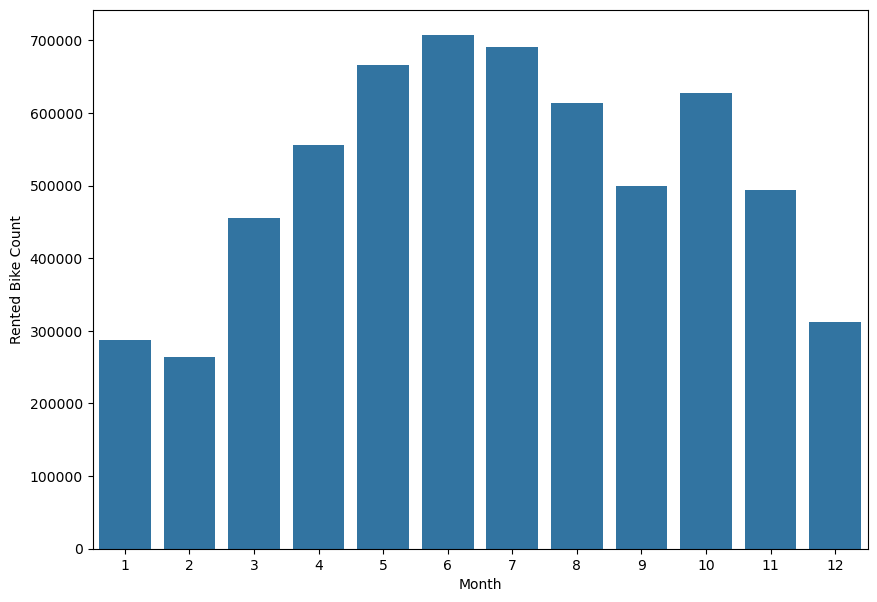

In [94]:
plt.figure(figsize=(10,7))
month = df.groupby("Month").sum().reset_index()
sns.barplot(x="Month",y="Rented Bike Count",data=month)

<Axes: xlabel='Day', ylabel='Rented Bike Count'>

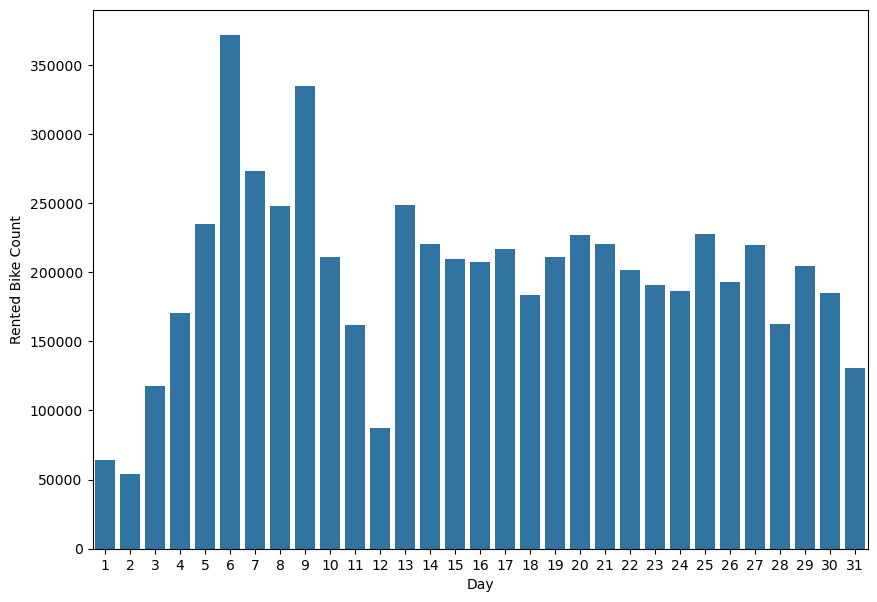

In [96]:
plt.figure(figsize=(10,7))
day = df.groupby("Day").sum().reset_index()
sns.barplot(x="Day",y="Rented Bike Count",data=day)

<Axes: xlabel='Hour', ylabel='Rented Bike Count'>

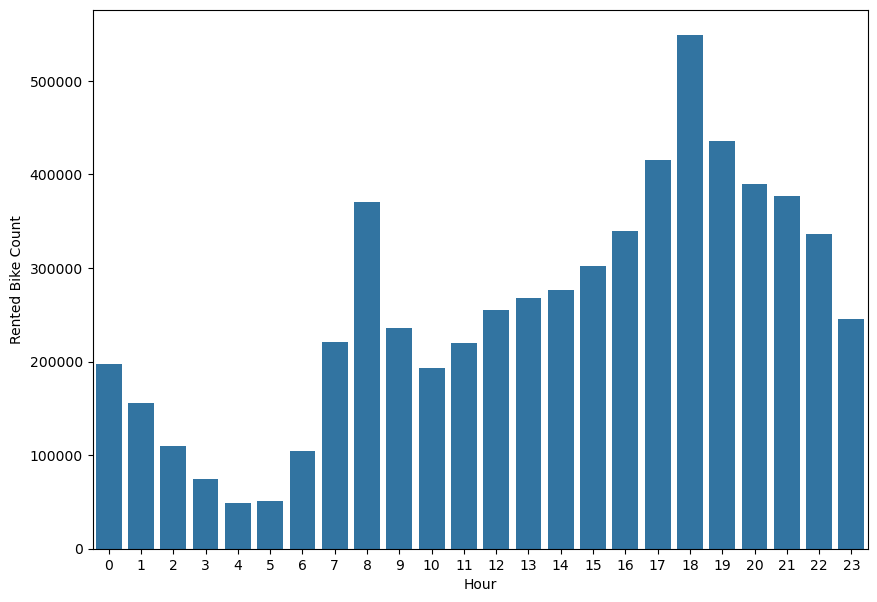

In [98]:
plt.figure(figsize=(10,7))
hour = df.groupby("Hour").sum().reset_index()
sns.barplot(x="Hour",y="Rented Bike Count",data=hour)

<Axes: xlabel='Holiday', ylabel='Rented Bike Count'>

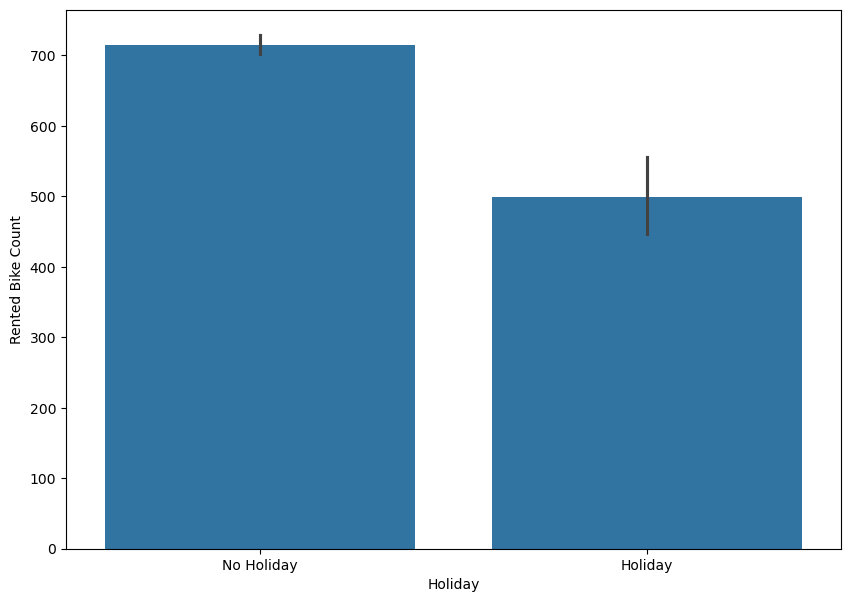

In [100]:
plt.figure(figsize=(10,7))

sns.barplot(x="Holiday",y="Rented Bike Count",data=df)

<Axes: xlabel='Seasons', ylabel='Rented Bike Count'>

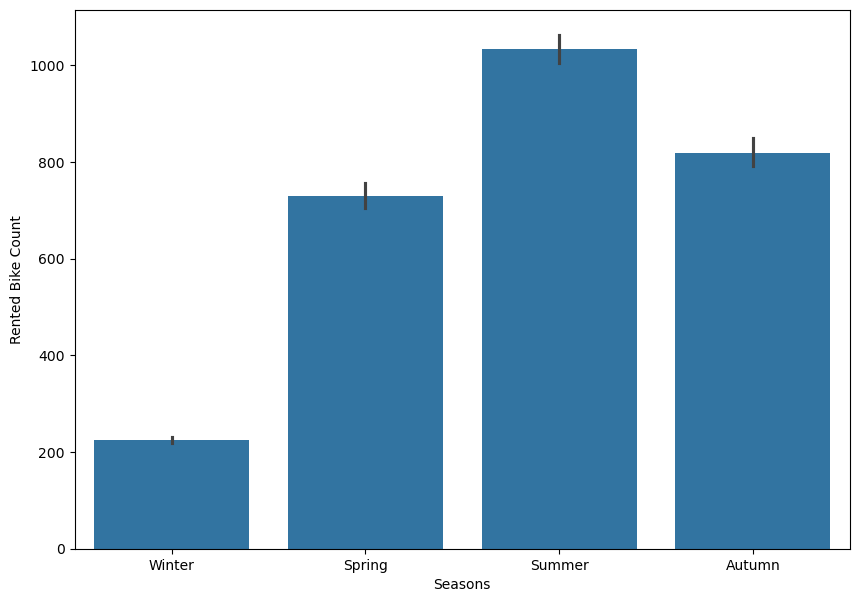

In [102]:
plt.figure(figsize=(10,7))

sns.barplot(x="Seasons",y="Rented Bike Count",data=df)

<Axes: xlabel='Snowfall (cm)', ylabel='Rented Bike Count'>

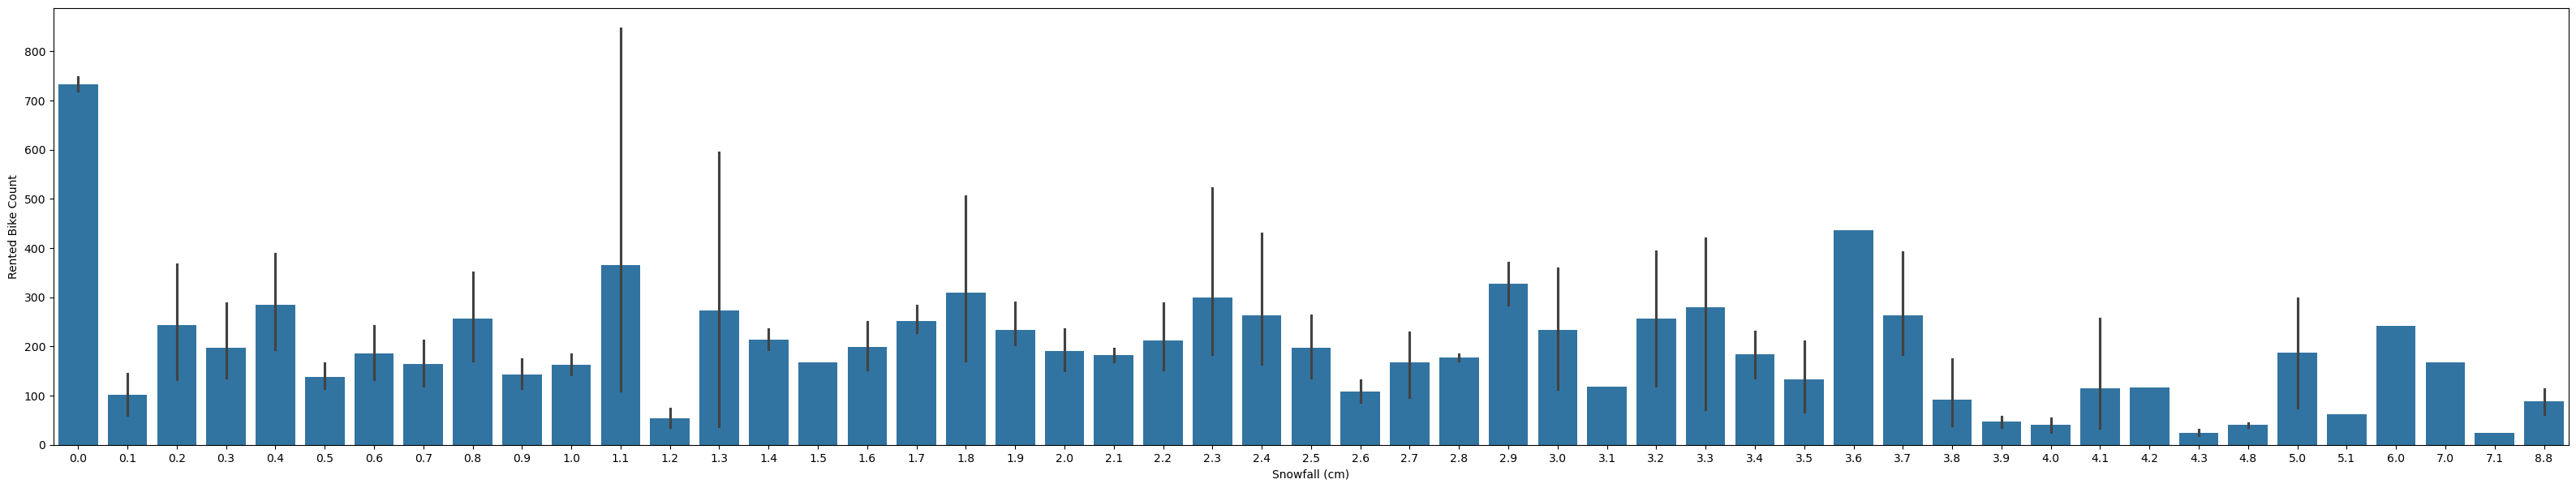

In [108]:
plt.figure(figsize=(40,7))

sns.barplot(x="Snowfall (cm)",y="Rented Bike Count",data=df)

<Figure size 4000x700 with 0 Axes>

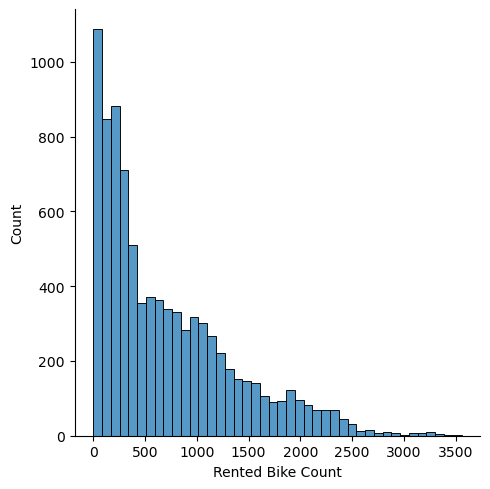

In [112]:
plt.figure(figsize=(40,7))
sns.displot(df["Rented Bike Count"])

<Figure size 4000x700 with 0 Axes>

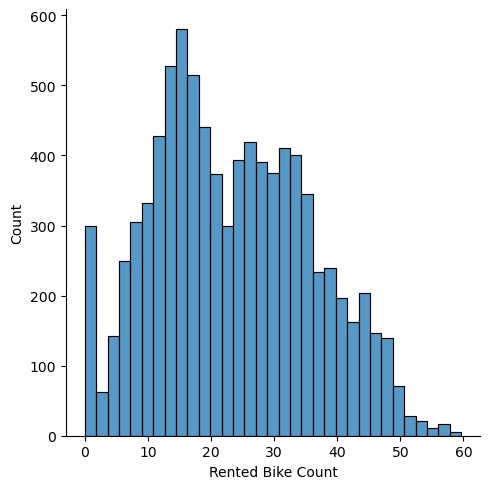

In [114]:
plt.figure(figsize=(40,7))
sns.displot(np.sqrt(df["Rented Bike Count"]))

In [128]:
#skewed data
df[['Rented Bike Count','Hour','Temperature(°C)','Humidity(%)','Wind speed (m/s)','Visibility (10m)','Dew point temperature(°C)',
   'Solar Radiation (MJ/m2)','Rainfall(mm)','Snowfall (cm)','Day','Month','year']].skew().sort_values(ascending=True) #negative values are left skew and positive value are rightskewed

year                         -2.978262
Visibility (10m)             -0.701786
Dew point temperature(°C)    -0.367298
Temperature(°C)              -0.198326
Month                        -0.010458
Hour                          0.000000
Day                           0.007522
Humidity(%)                   0.059579
Wind speed (m/s)              0.890955
Rented Bike Count             1.153428
Solar Radiation (MJ/m2)       1.504040
Snowfall (cm)                 8.440801
Rainfall(mm)                 14.533232
dtype: float64

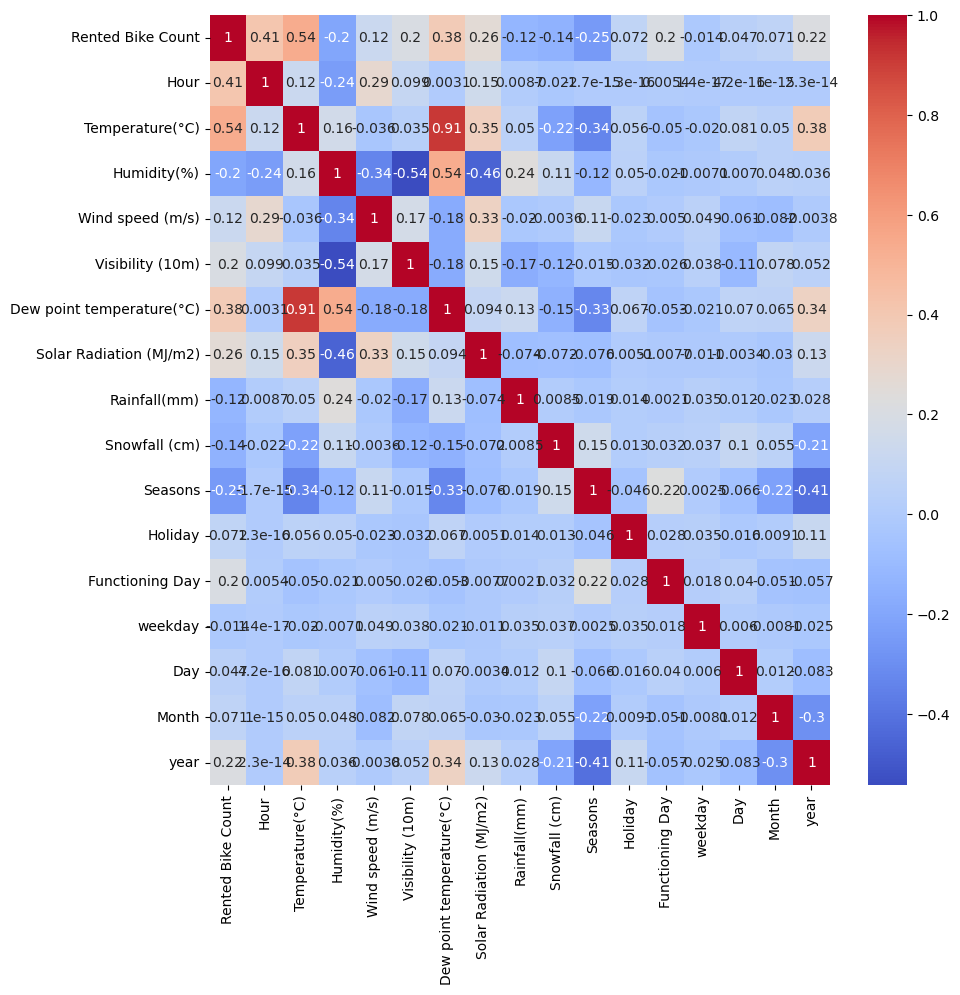

In [156]:
#oulier,will se if there are any outliers ,we can find it by scattered plot box plot ,for removing it we can use ztest ,data distribution 
#remove multicollinearity 



import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
for col in df.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df[col])
plt.figure(figsize=(10,10)) 
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.show()
#red is strong positive position and dark blue is negative position


In [162]:
drop = Dew point temperature

SyntaxError: invalid syntax (1654815404.py, line 1)

In [172]:
def get_vif(df):
    vif = pd.DataFrame()
    vif["variables"] = df.columns  
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]   
    return vif

In [190]:
not_for_vif = ["Day", "Month", "Year", "Rented Bike Count"]
selected_columns = [i for i in df.describe().columns if i not in not_for_vif]

def get_vif(df):
    vif = pd.DataFrame()
    vif["variables"] = df.columns
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif

vif_result = get_vif(df[selected_columns])
print(vif_result)


                   variables         VIF
0                       Hour    4.450547
1            Temperature(°C)  188.496720
2                Humidity(%)  186.877169
3           Wind speed (m/s)    4.811966
4           Visibility (10m)   10.313000
5  Dew point temperature(°C)  126.950456
6    Solar Radiation (MJ/m2)    2.888695
7               Rainfall(mm)    1.103251
8              Snowfall (cm)    1.127819
9                       year  397.756221


In [186]:
df[[i for i in df.describe().columns if i not in not_for_vif]]

,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),year
0,0,-5.2,37,2.2,2000,0.0,0.0,0.0,2017
1,1,-5.5,38,0.8,2000,0.0,0.0,0.0,2017
2,2,-6.0,39,1.0,2000,0.0,0.0,0.0,2017
3,3,-6.2,40,0.9,2000,0.0,0.0,0.0,2017
4,4,-6.0,36,2.3,2000,0.0,0.0,0.0,2017
...,...,...,...,...,...,...,...,...,...
8755,19,4.2,34,2.6,1894,0.0,0.0,0.0,2018
8756,20,3.4,37,2.3,2000,0.0,0.0,0.0,2018
8757,21,2.6,39,0.3,1968,0.0,0.0,0.0,2018
8758,22,2.1,41,1.0,1859,0.0,0.0,0.0,2018


In [192]:
not_for_vif = ["Day", "Month", "Year", "Dew point temperature(°C)", "Rented Bike Count"]
selected_columns = [i for i in df.describe().columns if i not in not_for_vif]

def get_vif(df):
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    import pandas as pd
    
    vif = pd.DataFrame()
    vif["variables"] = df.columns
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif

vif_result = get_vif(df[selected_columns])
print(vif_result)


                 variables        VIF
0                     Hour   4.442155
1          Temperature(°C)   3.512717
2              Humidity(%)  23.256531
3         Wind speed (m/s)   4.804338
4         Visibility (10m)  10.244374
5  Solar Radiation (MJ/m2)   2.751025
6             Rainfall(mm)   1.089105
7            Snowfall (cm)   1.122651
8                     year  53.659139


In [194]:
df.drop(["Dew point temperature(°C)"],axis=1,inplace=True)

In [198]:
#machine learning converts data into numerical format ...so now we have to convert the data into numerical format 
#encoding 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Seasons                  8760 non-null   object 
 10  Holiday                  8760 non-null   object 
 11  Functioning Day          8760 non-null   object 
 12  weekday                  8760 non-null   object 
 13  Day                      8760 non-null   int32  
 14  Month                   

In [200]:
cat_features = ["Seasons "," Holiday","Functioning Day "," weekday"]

In [202]:
df["Holiday"].value_counts()

Holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64

In [204]:
df["Functioning Day"].value_counts()

Functioning Day
Yes    8465
No      295
Name: count, dtype: int64

In [214]:
df["weekday"].value_counts()

weekday
Sunday       1296
Wednesday    1272
Tuesday      1272
Thursday     1248
Saturday     1248
Friday       1224
Monday       1200
Name: count, dtype: int64

In [210]:
df["Holiday"] = df["Holiday"].map({"No Holiday":0,"Holiday":1})
df["Functioning Day"] = df["Functioning Day"].map({"No":0,"Yes":1})


In [216]:
df_season = pd.get_dummies(df["Seasons"], drop_first = True)
df_weekday = pd.get_dummies(df["weekday"], drop_first = True)

In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Seasons                  8760 non-null   object 
 10  Holiday                  8760 non-null   int64  
 11  Functioning Day          8760 non-null   int64  
 12  weekday                  8760 non-null   object 
 13  Day                      8760 non-null   int32  
 14  Month                   

In [220]:
df = pd.concat([df,df_season,df_weekday],axis=1)

In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Seasons                  8760 non-null   object 
 10  Holiday                  8760 non-null   int64  
 11  Functioning Day          8760 non-null   int64  
 12  weekday                  8760 non-null   object 
 13  Day                      8760 non-null   int32  
 14  Month                   

In [224]:
df.drop(["Seasons","weekday"],axis = 1,inplace=True)

In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Holiday                  8760 non-null   int64  
 10  Functioning Day          8760 non-null   int64  
 11  Day                      8760 non-null   int32  
 12  Month                    8760 non-null   int32  
 13  year                     8760 non-null   int32  
 14  Spring                  

In [228]:
df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,...,year,Spring,Summer,Winter,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
0,254,0,-5.2,37,2.2,2000,0.0,0.0,0.0,0,...,2017,False,False,True,False,False,False,True,False,False
1,204,1,-5.5,38,0.8,2000,0.0,0.0,0.0,0,...,2017,False,False,True,False,False,False,True,False,False
2,173,2,-6.0,39,1.0,2000,0.0,0.0,0.0,0,...,2017,False,False,True,False,False,False,True,False,False
3,107,3,-6.2,40,0.9,2000,0.0,0.0,0.0,0,...,2017,False,False,True,False,False,False,True,False,False
4,78,4,-6.0,36,2.3,2000,0.0,0.0,0.0,0,...,2017,False,False,True,False,False,False,True,False,False


In [230]:
df.shape

(8760, 23)

In [236]:
#split the data
x = df.drop("Rented Bike Count",axis=1)
y = df["Rented Bike Count"]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2023)
print("shape of x_train: ",x_train.shape)
print("shape of y_train: ",y_train.shape)
print("shape of x_test: ",x_test.shape)
print("shape of y_test: ",y_test.shape)

shape of x_train:  (7008, 22)
shape of y_train:  (7008,)
shape of x_test:  (1752, 22)
shape of y_test:  (1752,)


In [242]:
#scaling
sc = StandardScaler()
sc.fit(x_train)


x_train = sc.transform(x_train)
x_test = sc.transform(x_test)

In [244]:
x_train[:2]

array([[ 1.51118219,  0.05556521, -2.10940521,  0.46658045,  0.92262892,
        -0.65681529, -0.12916836, -0.17535463, -0.22754885,  0.18254726,
        -1.32928272,  1.58736786,  0.30459857,  1.74132735, -0.58152447,
        -0.57866842, -0.39840954, -0.40773843, -0.41815465, -0.40773843,
         2.4655198 , -0.41815465],
       [ 0.93371229,  1.00382241, -0.25185689,  1.82005277,  0.92262892,
         0.82386154, -0.12916836, -0.17535463, -0.22754885,  0.18254726,
        -1.10164234,  1.58736786,  0.30459857, -0.57427456,  1.71961809,
        -0.57866842, -0.39840954, -0.40773843, -0.41815465,  2.45255275,
        -0.40559398, -0.41815465]])

In [246]:
sc.mean_


array([1.15323916e+01, 1.28319920e+01, 5.81522546e+01, 1.71738014e+00,
       1.44041795e+03, 5.67796804e-01, 1.52539954e-01, 7.52283105e-02,
       4.92294521e-02, 9.67751142e-01, 1.56787957e+01, 6.51341324e+00,
       2.01791510e+03, 2.48002283e-01, 2.52711187e-01, 2.50856164e-01,
       1.36986301e-01, 1.42551370e-01, 1.48829909e-01, 1.42551370e-01,
       1.41267123e-01, 1.48829909e-01])

In [248]:
sc.scale_

array([6.92676802e+00, 1.20220548e+01, 2.04570722e+01, 1.03437653e+00,
       6.06508248e+02, 8.64469525e-01, 1.18093896e+00, 4.29006703e-01,
       2.16346743e-01, 1.76660323e-01, 8.78578762e+00, 3.45640534e+00,
       2.78737249e-01, 4.31853159e-01, 4.34566730e-01, 4.33505881e-01,
       3.43832888e-01, 3.49614755e-01, 3.55920731e-01, 3.49614755e-01,
       3.48296889e-01, 3.55920731e-01])

In [250]:
#training ml model 
#linear regression model 
from sklearn.linear_model import LinearRegression

In [252]:
lr = LinearRegression()
lr.fit(x_train , y_train)

LinearRegression()

In [254]:
y_pred = lr.predict(x_test )

In [256]:
y_pred

array([  82.875826  ,  976.47642256, 1409.37670678, ..., 1544.96839026,
        504.51433769,  803.78036478])

In [262]:
#model evaluation
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score 

In [264]:
MSE = mean_squared_error(y_test,y_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y_test,y_pred)
R2 = r2_score(y_test,y_pred)

print(f"MSE: {MSE}")
print(f"RMSE: {RMSE}")
print(f"MAE: {MAE}")
print(f"R2: {R2}")

MSE: 188944.76470240724
RMSE: 434.67777111603857
MAE: 330.9044419713851
R2: 0.5371041582058085


In [272]:
def get_metrics(y_true,y_pred,model_name):
    MSE = mean_squared_error(y_test,y_pred)
    RMSE = np.sqrt(MSE)
    MAE = mean_absolute_error(y_test,y_pred)
    R2 = r2_score(y_test,y_pred)
    print(f" {model_name} : ['MSE':{round(MSE,3)},'RMSE':{round(RMSE,3)},'MAE':{round(MAE,3)},'R2':{round(R2,3)}]")


In [274]:
get_metrics(y_test,y_pred,"LinearRegression")

 LinearRegression : ['MSE':188944.765,'RMSE':434.678,'MAE':330.904,'R2':0.537]


In [279]:
!pip install xgboost

In [281]:
#train multiple models 
from sklearn.linear_model import Ridge,Lasso
from sklearn.preprocessing  import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [283]:
rir = Ridge().fit(x_train,y_train)
y_pred_rir = rir.predict(x_test)

lar= Lasso().fit(x_train,y_train)
y_pred_lar = lar.predict(x_test)

poly = PolynomialFeatures(2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.fit_transform(x_test)
poly_r = LinearRegression().fit(x_train_poly,y_train)
y_pred_poly = poly_r.predict(x_test_poly)

svr= SVR().fit(x_train,y_train)
y_pred_svr = svr.predict(x_test)


knnr= KNeighborsRegressor().fit(x_train,y_train)
y_pred_knnr = knnr.predict(x_test)

dtr= DecisionTreeRegressor().fit(x_train,y_train)
y_pred_dtr = dtr.predict(x_test)

rfr= RandomForestRegressor().fit(x_train,y_train)
y_pred_rfr = rfr.predict(x_test)

xgbr= XGBRegressor().fit(x_train,y_train)
y_pred_xgbr = xgbr.predict(x_test)


In [287]:
get_metrics(y_test,y_pred_rir,"Ridge")
get_metrics(y_test,y_pred_lar,"Lasso")
get_metrics(y_test,y_pred_poly,"PolynomialFeature")
get_metrics(y_test,y_pred_svr,"SVR")
get_metrics(y_test,y_pred_knnr,"KNNR")
get_metrics(y_test,y_pred_dtr,"DecisionTreeRegressor")
get_metrics(y_test,y_pred_rfr,"RandomForestRegressor")
get_metrics(y_test,y_pred_xgbr,"XGBRegressor")

 Ridge : ['MSE':188944.168,'RMSE':434.677,'MAE':330.898,'R2':0.537]
 Lasso : ['MSE':188895.35,'RMSE':434.621,'MAE':330.551,'R2':0.537]
 PolynomialFeature : ['MSE':125312.253,'RMSE':353.995,'MAE':248.202,'R2':0.693]
 SVR : ['MSE':318011.649,'RMSE':563.925,'MAE':386.276,'R2':0.221]
 KNNR : ['MSE':102739.999,'RMSE':320.531,'MAE':210.222,'R2':0.748]
 DecisionTreeRegressor : ['MSE':86180.527,'RMSE':293.565,'MAE':166.815,'R2':0.789]
 RandomForestRegressor : ['MSE':40483.07,'RMSE':201.204,'MAE':120.503,'R2':0.901]
 XGBRegressor : ['MSE':33114.133,'RMSE':181.973,'MAE':113.528,'R2':0.919]


In [ ]:
#we will use randomforest and xgbr for finetunning as they are giving good prediction

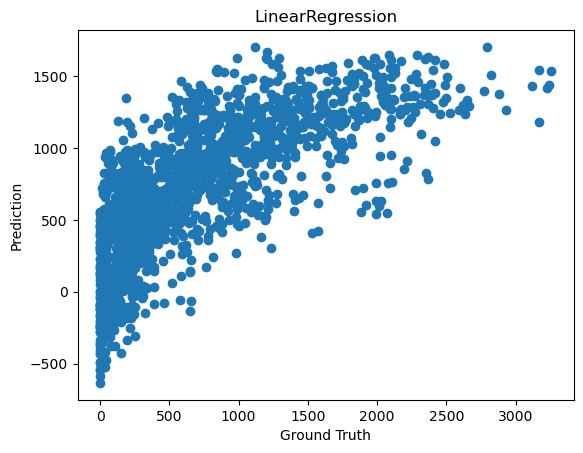

In [293]:
#visualise model prediction 
#linear regression
plt.scatter(y_test , y_pred)
plt.title("LinearRegression")
plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.show()

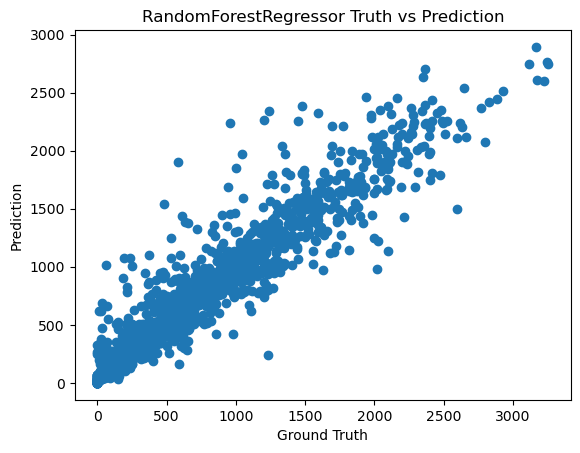

In [295]:
plt.scatter(y_test , y_pred_rfr)
plt.title("RandomForestRegressor Truth vs Prediction")
plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.show()

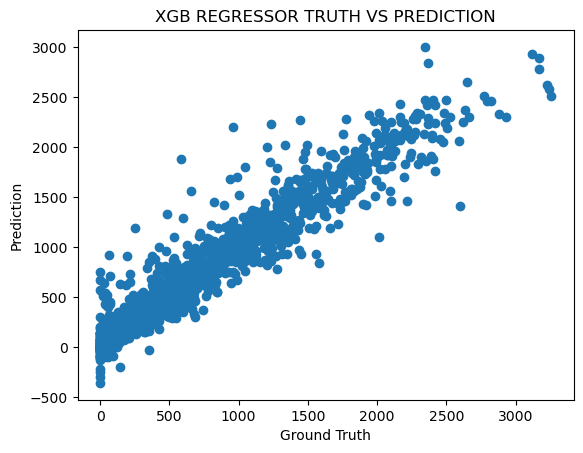

In [299]:
plt.scatter(y_test , y_pred_xgbr)
plt.title("XGB REGRESSOR TRUTH VS PREDICTION")
plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.show()

In [305]:
from sklearn.model_selection import RandomizedSearchCV


# Number of trees in the random forest
n_estimators = [int(x) for x in np.linspace(start=200, stop=2000, num=10)]  # Corrected np.linespace to np.linspace

# Number of features to consider at every split
max_features = ['auto', 'sqrt']

# Maximum number of levels allowed in each decision tree
max_depth = [int(x) for x in np.linspace(10, 120, num=12)]  # Corrected np.linespace to np.linspace

# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]

# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]

# Method of selecting samples for training each tree
bootstrap = [True, False]

# Create the random grid
random_grid = {
    'n_estimators': n_estimators,
    'max_features': max_features,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'bootstrap': bootstrap
}

print(random_grid)


{'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000], 'max_features': ['auto', 'sqrt'], 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'bootstrap': [True, False]}


In [310]:
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Record the start time
start_time = time.time()  # Corrected "start time" to "start_time"

# Initialize the Random Forest Regressor
rf = RandomForestRegressor()

# Randomized search of parameters using 3-fold cross-validation
# Search across 100 different combinations, and use all available cores
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=random_grid,
    n_iter=100,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit the random search model
rf_random.fit(x_train, y_train)

# Make predictions
y_pred_rf_random = rf_random.predict(x_test)

# Print the time taken for training
print("Time taken to train using RandomizedSearchCV:", time.time() - start_time)



Fitting 3 folds for each of 100 candidates, totalling 300 fits


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
123 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
69 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\Admin\anaconda3\Lib\site-package

Time taken to train using RandomizedSearchCV: 1315.3748302459717


In [314]:
get_metrics(y_test,y_pred_rf_random,"RandomForestRegressor FineTunning")

 RandomForestRegressor FineTunning : ['MSE':37367.497,'RMSE':193.307,'MAE':121.737,'R2':0.908]


In [318]:
rf_random.best_params_

{'n_estimators': 400,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 120,
 'bootstrap': False}

In [322]:
rf_tuned= RandomForestRegressor(n_estimators= 400,
 min_samples_split= 2,
 min_samples_leaf= 1,
 max_features= 'sqrt',
 max_depth= 120,
 bootstrap= False
)
rf_tuned.fit(x_train,y_train)
y_pred_rf_tuned = rf_tuned.predict(x_test)
get_metrics(y_test,y_pred_rf_random,"RandomForestRegressor with best parameters")

 RandomForestRegressor with best parameters : ['MSE':37367.497,'RMSE':193.307,'MAE':121.737,'R2':0.908]


In [332]:

from sklearn.model_selection import RandomizedSearchCV


# Record the start time
start_time = time.time()

# Define the parameter grid
params= {
    
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 6, 10, 15,20],
    
    'subsample':np.arange (0.5, 1.0, 0.1),
    'colsample_bytree':np.arange(0.4, 1.0,0.1),
    'colsample_bylevel':np.arange(0.4, 1.0,0.1),
    'n_estimators':[100,500,1000]}
xgbr = XGBRegressor(seed = 20)


# Randomized search with 3-fold cross-validation
rscv= RandomizedSearchCV(
    estimator=xgbr,
    param_distributions=params,
    n_iter=25,
    cv=5,
    verbose=1,

)

# Fit the random search model
rscv.fit(x_train, y_train)

# Make predictions
y_pred_xgb_random = rscv.predict(x_test)
get_metrics (y_test,y_pred_xgb_random,"XGBRegressor with best parameters")


# Print the time taken for training
print("Time taken to train using RandomizedSearchCV:", time.time() - start_time)
print("Best parameters:",rscv.best_params_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits
 XGBRegressor with best parameters : ['MSE':29274.628,'RMSE':171.098,'MAE':100.926,'R2':0.928]
Time taken to train using RandomizedSearchCV: 275.4159162044525
Best parameters: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8999999999999999, 'colsample_bylevel': 0.8999999999999999}


In [336]:
xgbr = XGBRegressor(subsample=0.7,
                   n_estimators=100,
                   max_depth= 10,
                   learning_rate= 0.1,
                   colsample_bytree= 0.9,
                   colsample_bylevel= 0.9,
                   seed=20 )
xgbr.fit(x_train,y_train)
y_pred_tuned = xgbr.predict(x_test)
get_metrics (y_test,y_pred_tuned,"XGBRegressor with best parameters")
 
                   

                   



 XGBRegressor with best parameters : ['MSE':29274.628,'RMSE':171.098,'MAE':100.926,'R2':0.928]


In [340]:
#for saving machine learning model 
import pickle
import os
dir = r"C:\Users\Admin\Desktop\seoul bike prediction\models"
model_file_name = "xgboost regressor_r2_0_928_v1.pkl"

model_file_path =  os.path.join(dir,model_file_name )
model_file_path

pickle.dump(xgbr, open(model_file_path,"wb"))#we will dump the file into binary format 

In [342]:
x_test[0,:]

array([ 1.07807977,  0.22192612,  0.77468297,  1.82005277, -1.26200749,
       -0.25194272, -0.12916836, -0.17535463, -0.22754885, -5.47803337,
       -1.21546253,  1.00873202,  0.30459857,  1.74132735, -0.58152447,
       -0.57866842, -0.39840954, -0.40773843, -0.41815465, -0.40773843,
       -0.40559398, -0.41815465])

In [348]:
x_test[1,:]

array([-0.65432992,  1.24504573,  0.23697162, -0.5001855 ,  0.56154562,
       -0.28664608, -0.12916836, -0.17535463, -0.22754885,  0.18254726,
        0.94712104,  0.14077827,  0.30459857, -0.57427456,  1.71961809,
       -0.57866842, -0.39840954, -0.40773843, -0.41815465, -0.40773843,
        2.4655198 , -0.41815465])

In [344]:
y_test


3859       0
5647    1213
6735    1391
374      292
5791    1130
        ... 
1992     195
930      316
5634    2405
3291     164
6416     721
Name: Rented Bike Count, Length: 1752, dtype: int64

In [362]:
#dump scaling parameters 
import pickle

sc_dump_path = r"C:\Users\Admin\Desktop\seoul bike prediction\models\scaler.pkl"  # Add file name with .pkl extension
with open(sc_dump_path, "wb") as file:
    pickle.dump(sc, file)
